# Example notebook for running simulations with QSQlab

## Imports

In [1]:
# General imports
import numpy as np

# Qiskit related
from qiskit import QuantumCircuit

# Specific to qsqlab
from qsqlab.sequencer import BenchmarkSequencer 
from qsqlab.noise import NoisyAerSimulator
from qsqlab.data_processing.qsq_post_processing import QSQPostProcessing

# Setting logging level
import logging
logging.getLogger("qsqlab").setLevel(logging.INFO)

## Setting up a Simulator Backend, QuantumCircuit, single-qubit sequencer

In [2]:
# This backend is based on the AerSimulator and sets measurement, state preparation and other 
# general types of noise like depolarizing, thermal relaxation, etc.
backend = NoisyAerSimulator(
    # State-depenedent measurement errors for [|0>, |1>] respectively  
    measurement_error_prob = [0.01, 0.012], 
    )

backend.add_depolarizing_error(param=0.001) # depolarizing noise

# Coherent residual rotation in the X-axis with its respective amplitude
backend.add_coherent_unitary_error({"X": 0.01})


<QuantumError[c2322c3e197946eba6f7e60f23a82585], num_qubits=1, size=1, probabilities=[np.float64(1.0)]>

In [3]:
# Create instance of single-qubit QuantumCircuit
qc = QuantumCircuit(1)

# Create instance of Sequencer
sequencer = BenchmarkSequencer(
    backend = backend,
    qc = qc
    )

## Sequence of noisy $R_x(\frac{\pi}{2})$ rotations

In [4]:
# list of circuit depths (don't choose uneven depths for pi/2 rotations when running QSQ)
depths =  2*[2*x for x in range(180)]

# Circuit execution
results = sequencer.run_circuits(
    depths = depths, 
    shots= 1000, 
    qubit= 0, # qubit register to apply sequencing

    gate= "rx", # optionally use "sqrtx" and drop the theta keyword
    theta = np.pi/2,
    )


### Processing data and obtaining performance indicators:

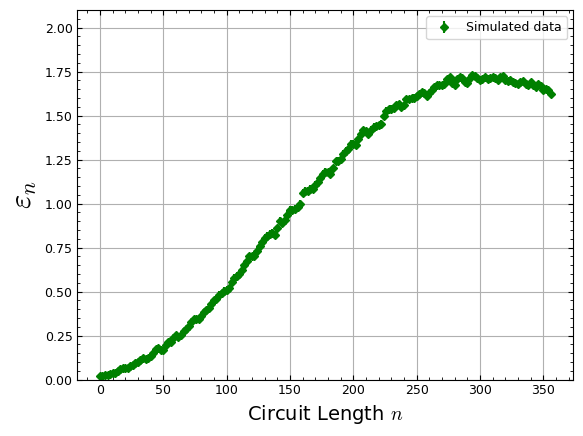

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% QSQBenchmarkResult %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

============================== Short Sequnce Results =============================
short_seq_fidelity_lb = 0.97555171, +/- None
state_prep_lb = 0.98200000, 
measurement_lb = 0.01800000, 
============================= Long Sequnce Results =============================
long_seq_fidelity_lb:        Fid    >=  0.99951429 +/- 0.00007370/0.00020725
long_seq_amplitude_bound:   |λ_1|   >= 0.99948690   obtained from epsilon_318
long_seq_angle_bound:        |φ|    <= 0.00934770 rad   obtained from Xi_13
============================= Additional Information =============================
error probability map = 0: 0.01000000, 2: 0.00800000, 4: 0.01000000, 6: 0.01500000, ...
εₖ map = 0: 0.01800000, 2: 0.01800000, 4: 0.02500000, 6: 0.02750000, ...
backend

In [5]:
# Process the data and obtain performance indicators
data = QSQPostProcessing(
    sequencer_data = results,
    simulation=True, 
    save=False
    )

print(data.results)